# Entrega 2 — EDA: ¿gana el underdog?

**Pregunta.** ¿Ganará el equipo no favorito (*underdog*) un partido, dadas las probabilidades implícitas
pre-partido y métricas construidas a partir de sus jugadores titulares?

**Una fila = un partido.** Target: `gano_no_favorito` (True si ganó el underdog; empate o derrota = False).

**De dónde salen los datos.** Este notebook no toca la base: lee el **Silver** que construye el DAG
`underdog_pipeline` de Airflow (`source-db` PostgreSQL → consultas SQL → Bronze → Silver → quality checks).
Para las hipótesis que necesitan información que *no* está en Silver a propósito (partidos excluidos, niveles
por equipo) lee las capas intermedias que el mismo DAG persiste.

**Momento de la predicción.** Después de publicadas las alineaciones (~1 h antes) y antes del pitazo inicial.
Una columna solo puede ser feature si existe en ese momento.

**Cómo leer las hipótesis.** Cada una tiene seis casillas:
**1. Hipótesis · 2. Por qué podría ser cierta · 3. Movimientos (máx. 2) · 4. Resultado · 5. Zona · 6. Decisión.**
Semáforo: 🟢 confirmada · 🟡 inconclusa · 🔴 refutada. Cada análisis termina en una decisión sobre filas o columnas.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "include" / "config.py").exists())
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)

from include.config import AUDIT_DIR, INTERMEDIATE_DIR, SILVER_DATASET_PATH, TARGET_COLUMN, UNDERDOG_GAP_CANDIDATES, UNDERDOG_MIN_PROB_GAP
from include.src import columns as catalog
from include.src.profiling import dataset_profile, stability_by_gap_band, threshold_sensitivity
from include.src.quality_check import run_quality_checks, single_feature_auc

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
BLUE, ORANGE, GRAY, INK = "#2a78d6", "#eb6834", "#8a8984", "#52514e"
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRAY, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "legend.frameon": False,
})

silver = pd.read_parquet(SILVER_DATASET_PATH)
print(f"Silver: {silver.shape[0]:,} filas x {silver.shape[1]} columnas".replace(",", "."))

Silver: 17.959 filas x 31 columnas


# Parte 1 — Perfil del dataset

In [2]:
profile = dataset_profile(silver)
t = profile["target"]
pd.Series({
    "filas": profile["filas"],
    "columnas": profile["columnas"],
    "una fila es": profile["una_fila_es"],
    "clave": profile["clave"],
    "match_id duplicados": profile["match_id_duplicados"],
    "columnas constantes": profile["columnas_constantes"] or "ninguna",
    "columnas con nulos": profile["columnas_con_nulos"],
    f"{TARGET_COLUMN} = True": f"{t['true']} ({t['pct_true']}%)",
    f"{TARGET_COLUMN} = False": f"{t['false']} ({t['pct_false']}%)",
    f"{TARGET_COLUMN} nulos": t["nulos"],
}, name="valor").to_frame()

,valor
filas,17959
columnas,31
una fila es,un partido
clave,match_id
match_id duplicados,0
columnas constantes,ninguna
columnas con nulos,6
gano_no_favorito = True,3654 (20.35%)
gano_no_favorito = False,14305 (79.65%)
gano_no_favorito nulos,0


### Tipos y rol de cada columna
El tipo solo no alcanza: importa el **rol**. De las 31 columnas, solo las marcadas como `feature` pueden entrar al modelo;
`match_id` es la clave, `fecha`/`temporada` sirven para cortar en el tiempo, `odds_source` y las probabilidades
local/visitante son trazabilidad, y `gano_no_favorito` es el target.

In [3]:
spec = {c.name: c for c in catalog.SILVER_COLUMNS}
roles = pd.DataFrame({
    "dtype": silver.dtypes.astype(str),
    "rol": [spec[c].role for c in silver.columns],
    "origen": [spec[c].origin for c in silver.columns],
})
print(roles["dtype"].value_counts().to_dict())
print(roles["rol"].value_counts().to_dict())
roles

{'float64': 21, 'str': 6, 'int64': 2, 'datetime64[ns]': 1, 'bool': 1}
{'feature': 23, 'metadata': 3, 'auxiliar': 3, 'identificador': 1, 'target': 1}


,dtype,rol,origen
match_id,int64,identificador,fuente
fecha,datetime64[ns],metadata,fuente
temporada,str,metadata,fuente
jornada,int64,feature,fuente
liga,str,feature,fuente
odds_source,str,metadata,calculada
prob_home,float64,auxiliar,calculada
prob_draw,float64,feature,calculada
prob_away,float64,auxiliar,calculada
equipo_favorito,str,feature,calculada


### Nulos

In [4]:
nulls = pd.DataFrame(profile["nulos"]).T
nulls

,nulos,pct_nulos,motivo
nofav_gk_overall_gap,4,0.022,nula si en el underdog o en el favorito ningún...
fav_formacion,2,0.011,las coordenadas Y de los titulares de campo vi...
nofav_att_overall_gap,2,0.011,nula si en el underdog o en el favorito ningún...
nofav_mid_overall_gap,2,0.011,nula si en el underdog o en el favorito ningún...
nofav_formacion,2,0.011,las coordenadas Y de los titulares de campo vi...
nofav_def_overall_gap,2,0.011,nula si en el underdog o en el favorito ningún...


**Decisión (nulos).** Solo 6 columnas tienen nulos y ninguna supera 4 filas (0,02%). Todos tienen motivo conocido:
coordenadas Y de la alineación vacías o en 0 en la fuente, que impiden ubicar al arquero, las líneas o la formación.
**No se imputan en Silver** para no inventar datos. En el modelado se imputan con la mediana del *train*
o se descartan esas filas: son tan pocas que ninguna decisión cambia el resultado.

### Distribución del target y asimetría

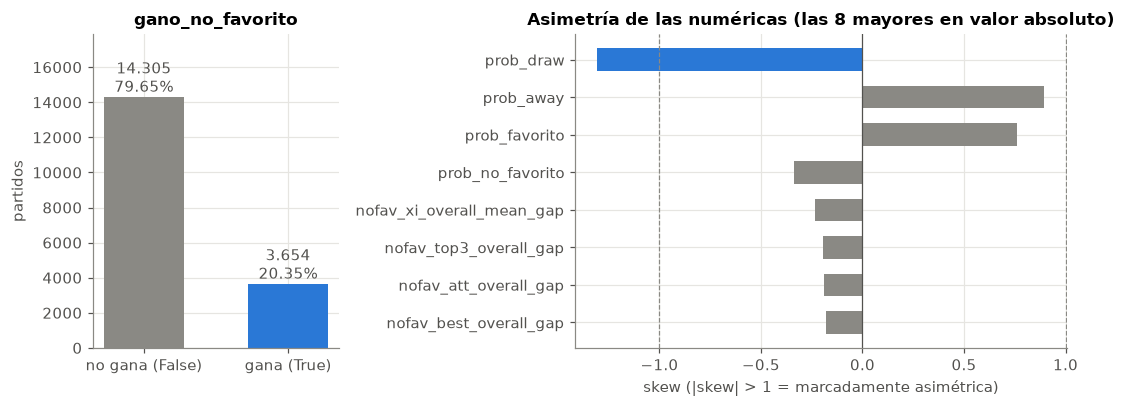

,prob_draw,prob_away,prob_favorito,prob_no_favorito,nofav_xi_overall_mean_gap,nofav_top3_overall_gap,nofav_att_overall_gap,nofav_best_overall_gap,nofav_def_overall_gap,nofav_mid_overall_gap,nofav_xi_height_mean_gap,nofav_fastest_sprint_speed_gap,nofav_best_marking_gap,nofav_strongest_strength_gap,nofav_overall_std_gap,nofav_worst_overall_gap,jornada,nofav_best_finishing_gap,nofav_best_reactions_gap,nofav_gk_overall_gap,prob_home,nofav_xi_age_mean_gap
skew,-1.305,0.896,0.76,-0.339,-0.235,-0.193,-0.19,-0.182,-0.141,-0.133,0.083,0.071,-0.067,0.065,-0.064,-0.057,0.042,-0.04,-0.032,0.018,-0.005,-0.003


In [5]:
skew = pd.Series(profile["asimetria"], name="skew")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [1, 2]})

counts = silver[TARGET_COLUMN].value_counts().reindex([False, True])
bars = ax1.bar(["no gana (False)", "gana (True)"], counts.values, color=[GRAY, BLUE], width=0.55)
for bar, n in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, n, f"{n:,}\n{n / len(silver):.2%}".replace(",", "."), ha="center", va="bottom", color=INK)
ax1.set_ylim(0, counts.max() * 1.25)
ax1.set_title("gano_no_favorito")
ax1.set_ylabel("partidos")

top = skew.reindex(skew.abs().sort_values(ascending=False).index).head(8)[::-1]
ax2.barh(top.index, top.values, color=[BLUE if abs(v) > 1 else GRAY for v in top.values], height=0.6)
ax2.axvline(0, color=INK, linewidth=0.8)
for x in (-1, 1):
    ax2.axvline(x, color=GRAY, linestyle="--", linewidth=0.8)
ax2.set_title("Asimetría de las numéricas (las 8 mayores en valor absoluto)")
ax2.set_xlabel("skew (|skew| > 1 = marcadamente asimétrica)")
plt.tight_layout()
plt.show()
skew.to_frame().T

**Decisión (target).** El underdog gana el **20,35%** de los partidos (3.654 de 17.959). Es un desbalance de la
realidad, no un error: **no se rebalancea en el EDA**. En el modelado se evalúa con **AUC y log-loss** (la *accuracy* no sirve:
decir siempre "no gana" ya da 79,65%) y se corta en el tiempo respetando la proporción.

**Decisión (asimetría).** La única columna con |skew| > 1 es `prob_draw` (−1,3): cola larga hacia empates improbables,
que son los partidos muy desparejos. Es una probabilidad acotada en [0, 1] y **no se transforma en Silver**. Si el modelo
es lineal, se prueba su logit. Las diferencias de jugadores (`nofav_*_gap`) son casi simétricas.

### Qué filas quedaron afuera y por qué
Cada partido excluido queda registrado con su motivo en `include/data/audit/excluded_matches.parquet`.

In [6]:
excluded = pd.read_parquet(AUDIT_DIR / "excluded_matches.parquet")
order = ["liga_sin_cuotas", "alineacion_incompleta", "sin_cuotas_1x2", "cuota_empate_incoherente", "sin_underdog_identificable", "partido_parejo"]
funnel = excluded["motivo"].value_counts().reindex(order).rename("partidos excluidos").to_frame()
funnel["etapa"] = ["prepare_matches"] * 4 + ["filter_valid_underdogs"] * 2
total = len(excluded) + len(silver)
print(f"Partidos en la fuente: {total:,} -> en Silver: {len(silver):,} ({len(silver) / total:.1%})".replace(",", "."))
funnel

Partidos en la fuente: 25.979 -> en Silver: 17.959 (69.1%)


,partidos excluidos,etapa
motivo,,
liga_sin_cuotas,3342,prepare_matches
alineacion_incompleta,2910,prepare_matches
sin_cuotas_1x2,33,prepare_matches
cuota_empate_incoherente,32,prepare_matches
sin_underdog_identificable,103,filter_valid_underdogs
partido_parejo,1600,filter_valid_underdogs


**Decisión.** Las cuatro primeras exclusiones son de alcance: sin cuotas no hay favorito, y sin alineación completa no hay
features de jugadores. Las dos últimas salen de la definición de underdog, y la hipótesis 1 muestra con números por qué
se filtran.

---
# Parte 2 — Cuatro hipótesis

## H1 · En los partidos muy parejos el underdog no está bien definido

| | |
|---|---|
| **1. Hipótesis** | Cuando las probabilidades de local y visitante son casi iguales, *quién* es el underdog depende de qué casa de apuestas se use. Esas filas tienen una etiqueta arbitraria y deben excluirse. |
| **2. Por qué podría ser cierta** | Dominio: cada casa fija su precio con su propio margen. Si la diferencia es de 1 punto, otra casa puede invertir el orden. El pipeline usa **una** casa por partido (Pinnacle o Bet365). |
| **3. Movimientos** | (1) % de partidos donde Pinnacle y Bet365 eligen distinto favorito, por tramo de \|prob_home − prob_away\|. (2) Tabla de sensibilidad para los umbrales 0; 0,02; 0,03; 0,05; 0,075; 0,10. |
| **Tipo** | Dominio, decide qué **filas** entran. |

Se usa `matches_with_target.parquet`: los partidos **antes** del filtro, con las cuotas de las 10 casas.

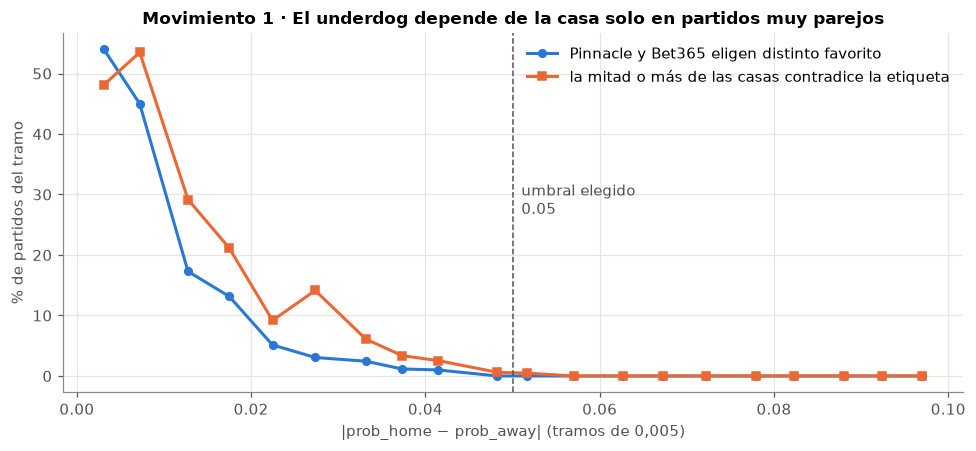

,banda,partidos,gap_medio,pct_favorito_cambia_ps_b365,pct_mercado_contradice
0,"(0.0, 0.005]",81,0.00,53.97,48.15
1,"(0.005, 0.01]",129,0.01,45.00,53.49
2,"(0.01, 0.015]",144,0.01,17.28,29.17
3,"(0.015, 0.02]",222,0.02,13.16,21.17
4,"(0.02, 0.025]",98,0.02,5.13,9.18
5,"(0.025, 0.03]",191,0.03,3.06,14.14
6,"(0.03, 0.035]",213,0.03,2.44,6.10
7,"(0.035, 0.04]",119,0.04,1.16,3.36
8,"(0.04, 0.045]",235,0.04,1.00,2.55
9,"(0.045, 0.05]",168,0.05,0.00,0.60


In [7]:
candidates = pd.read_parquet(INTERMEDIATE_DIR / "matches_with_target.parquet")
bands = stability_by_gap_band(candidates, width=0.005, upper=0.10)
bands = bands[bands["gap_medio"] <= 0.10]  # el último tramo (> 0,10) es el resto: siempre 0%
x = bands["gap_medio"]

fig, ax = plt.subplots()
ax.plot(x, bands["pct_favorito_cambia_ps_b365"], color=BLUE, marker="o", markersize=5, linewidth=2, label="Pinnacle y Bet365 eligen distinto favorito")
ax.plot(x, bands["pct_mercado_contradice"], color=ORANGE, marker="s", markersize=5, linewidth=2, label="la mitad o más de las casas contradice la etiqueta")
ax.axvline(UNDERDOG_MIN_PROB_GAP, color=INK, linestyle="--", linewidth=1)
ax.text(UNDERDOG_MIN_PROB_GAP + 0.001, 32, f"umbral elegido\n{UNDERDOG_MIN_PROB_GAP}", color=INK, va="top")
ax.set_xlabel("|prob_home − prob_away| (tramos de 0,005)")
ax.set_ylabel("% de partidos del tramo")
ax.set_title("Movimiento 1 · El underdog depende de la casa solo en partidos muy parejos")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
bands.head(12).round(2)

In [8]:
sensitivity = threshold_sensitivity(candidates, UNDERDOG_GAP_CANDIDATES)
sensitivity

,umbral,filas_quedan,filas_eliminadas,pct_eliminado,target_true,target_false,tasa_victoria_underdog_pct,tasa_victoria_favorito_pct,dif_media_prob,pct_favorito_cambia_ps_b365,pct_mercado_contradice,eliminadas_pct_favorito_cambia_ps_b365
0,0.000,19559,103,0.52,4192,15367,21.43,53.39,0.3068,1.14,1.32,67.74
1,0.020,18983,679,3.45,4005,14978,21.10,53.82,0.3158,0.11,0.33,33.16
2,0.030,18694,968,4.92,3903,14791,20.88,54.11,0.3203,0.04,0.14,24.07
3,0.050,17959,1703,8.66,3654,14305,20.35,54.70,0.3317,0.00,0.01,15.02
4,0.075,16967,2695,13.71,3365,13602,19.83,55.61,0.3475,0.00,0.01,9.85
5,0.100,15977,3685,18.74,3042,12935,19.04,56.51,0.3636,0.00,0.01,7.18


**4. Resultado.**
- Con gap ≤ 0,005 Pinnacle y Bet365 eligen **distinto favorito en el 54,0%** de los partidos. En el tramo siguiente es el 45,0%, y la mitad o más de las casas contradice la etiqueta en ~50%: es una moneda al aire.
- La discrepancia cae a 13,2% entre 0,015 y 0,02, a 1,0% entre 0,04 y 0,045, y es **0,0% en todos los tramos desde 0,045**.
- En la tabla, **0,05 es el menor umbral evaluado con 0,00% de partidos cuyo underdog cambia según la casa**. Saca 1.703 filas (8,66%): 103 sin underdog posible (probabilidades idénticas) y 1.600 parejos. Con 0,03 todavía quedan etiquetas que dependen de la casa (0,04%, y 0,14% contradichas por el mercado).
- Subir a 0,075 o 0,10 cuesta 5 a 10 puntos más de filas **sin ganar estabilidad** (ya era 0%). Además sesga el dataset hacia partidos desparejos: la tasa del underdog baja de 20,35% a 19,04%.

**5. Zona:** 🟢 **confirmada.**

**6. Decisión.** `UNDERDOG_MIN_PROB_GAP = 0.05` en `config.py`, y **se filtra**: entran solo los partidos con
|prob_home − prob_away| > 0,05. La columna `es_partido_parejo` desaparece (quedaría constante). El filtro también saca los 103
partidos sin underdog, así que `gano_no_favorito` no tiene nulos.

### Herramienta común para H2–H4: ¿una columna agrega información a lo que ya sabemos?
Una columna puede "estar asociada" al target y aun así no aportar nada nuevo, si esa información ya está en las cuotas.
Para medirlo se compara una regresión logística **sin** la columna contra otra **con** la columna:

- **Fuera de muestra (lo que importa):** se entrena con 2008/09–2013/14 y se mide en 2014/15–2015/16, partidos que el modelo
  nunca vio. Si agregar la columna no baja el *log-loss* ni sube el *AUC*, no aporta.
- **Test de razón de verosimilitud (LR):** si la mejora del ajuste dentro de muestra es más grande que la que daría el azar (p < 0,05).

La base siempre es el mercado: logit de `prob_no_favorito`, `prob_draw` y si el underdog es local.

In [9]:
df = silver.copy()
df["y"] = df[TARGET_COLUMN].astype(int)
df["logit_p_no_favorito"] = np.log(df["prob_no_favorito"] / (1 - df["prob_no_favorito"]))
df["underdog_local"] = (df["equipo_favorito"] == "visitante").astype(int)
MARKET = ["logit_p_no_favorito", "prob_draw", "underdog_local"]
TRAIN = df["temporada"] <= "2013/2014"
print(f"train: {TRAIN.sum():,} partidos (2008/09-2013/14) | test: {(~TRAIN).sum():,} partidos (2014/15-2015/16)".replace(",", "."))


def fit_logit(data, numeric, categorical=()):
    X = data[list(numeric) + list(categorical)].copy()
    X[list(numeric)] = X[list(numeric)].fillna(X.loc[TRAIN, list(numeric)].median())
    steps = [("num", StandardScaler(), list(numeric))]
    if categorical:
        steps.append(("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=100), list(categorical)))
    model = make_pipeline(ColumnTransformer(steps), LogisticRegression(C=1e6, max_iter=5000))
    model.fit(X[TRAIN], data.loc[TRAIN, "y"])
    p_test = model.predict_proba(X[~TRAIN])[:, 1]
    model.fit(X, data["y"])
    loglik = -log_loss(data["y"], model.predict_proba(X)[:, 1], normalize=False)
    return {"log_loss_test": log_loss(data.loc[~TRAIN, "y"], p_test), "auc_test": roc_auc_score(data.loc[~TRAIN, "y"], p_test),
            "loglik": loglik, "parametros": model[-1].coef_.size}


def compare(data, models: dict) -> pd.DataFrame:
    rows = {name: fit_logit(data, *spec) for name, spec in models.items()}
    table = pd.DataFrame(rows).T
    base = table.iloc[0]
    table["Δ log_loss vs 1ra"] = table["log_loss_test"] - base["log_loss_test"]
    table["Δ AUC vs 1ra"] = table["auc_test"] - base["auc_test"]
    lr = 2 * (table["loglik"] - table["loglik"].shift())
    dof = table["parametros"] - table["parametros"].shift()
    table["LR p vs fila anterior"] = [np.nan] + [stats.chi2.sf(s, d) for s, d in zip(lr[1:], dof[1:])]
    return table.drop(columns="loglik").astype(float).round(4)

train: 13.124 partidos (2008/09-2013/14) | test: 4.835 partidos (2014/15-2015/16)


## H2 · Si el XI del underdog es mejor, el underdog gana más de lo que el mercado ya descuenta

| | |
|---|---|
| **1. Hipótesis** | Cuando el once titular del underdog tiene mejor overall medio que el del favorito (`nofav_xi_overall_mean_gap` alto), el underdog gana **más seguido de lo que dicen las cuotas**. |
| **2. Por qué podría ser cierta** | Dominio: las cuotas se publican días antes y las alineaciones ~1 h antes. Si un favorito sale con suplentes, la cuota no lo sabía. Es el corazón de la pregunta del proyecto. |
| **3. Movimientos** | (1) Tasa real de victoria del underdog vs. probabilidad implícita media, por quintil de `nofav_xi_overall_mean_gap`. (2) Mercado vs. mercado + gap del XI, fuera de muestra. |
| **Tipo** | Dominio, decide la **columna** `nofav_xi_overall_mean_gap` y la expectativa del modelo. |

Lectura ingenua: {'XI del underdog peor o igual': '18.6%', 'XI del underdog mejor': '27.0%'}
Correlación del gap del XI con prob_no_favorito: 0.66


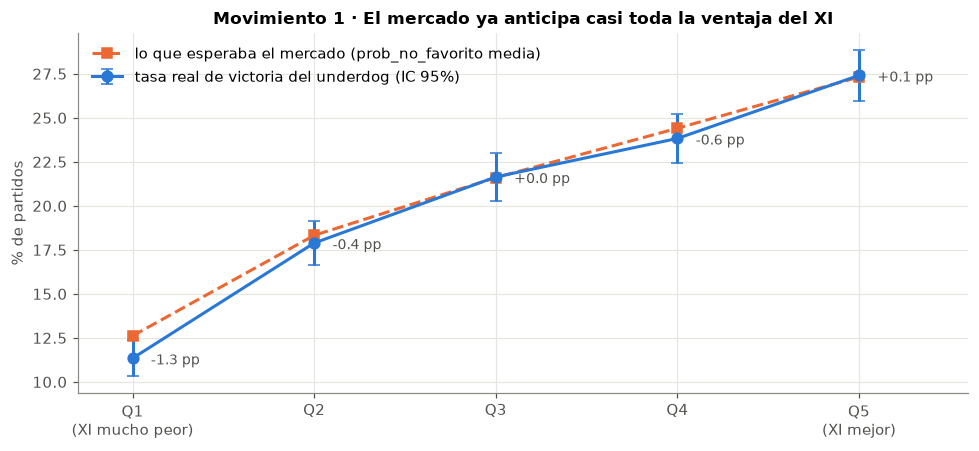

,partidos,tasa_real,prob_mercado,error_std,real_menos_mercado_pp
quintil_xi,,,,,
Q1\n(XI mucho peor),3685,0.1134,0.1262,0.0052,-1.2726
Q2,3600,0.1789,0.1832,0.0064,-0.4356
Q3,3572,0.2164,0.2160,0.0069,0.0364
Q4,3563,0.2383,0.2440,0.0071,-0.5765
Q5\n(XI mejor),3539,0.2741,0.2731,0.0075,0.0952


In [10]:
naive = df.groupby(df["nofav_xi_overall_mean_gap"] > 0)["y"].agg(["mean", "size"]).rename(index={False: "XI del underdog peor o igual", True: "XI del underdog mejor"})
print("Lectura ingenua:", {k: f"{v:.1%}" for k, v in naive["mean"].items()})
print(f"Correlación del gap del XI con prob_no_favorito: {df['nofav_xi_overall_mean_gap'].corr(df['prob_no_favorito']):.2f}")

df["quintil_xi"] = pd.qcut(df["nofav_xi_overall_mean_gap"], 5, labels=["Q1\n(XI mucho peor)", "Q2", "Q3", "Q4", "Q5\n(XI mejor)"])
by_q = df.groupby("quintil_xi", observed=True).agg(partidos=("y", "size"), tasa_real=("y", "mean"), prob_mercado=("prob_no_favorito", "mean"))
by_q["error_std"] = np.sqrt(by_q["tasa_real"] * (1 - by_q["tasa_real"]) / by_q["partidos"])
by_q["real_menos_mercado_pp"] = (by_q["tasa_real"] - by_q["prob_mercado"]) * 100

fig, ax = plt.subplots()
pos = np.arange(len(by_q))
ax.errorbar(pos, by_q["tasa_real"] * 100, yerr=1.96 * by_q["error_std"] * 100, color=BLUE, marker="o", markersize=7, linewidth=2, capsize=4, label="tasa real de victoria del underdog (IC 95%)")
ax.plot(pos, by_q["prob_mercado"] * 100, color=ORANGE, marker="s", markersize=7, linewidth=2, linestyle="--", label="lo que esperaba el mercado (prob_no_favorito media)")
for i, (real, gap) in enumerate(zip(by_q["tasa_real"] * 100, by_q["real_menos_mercado_pp"])):
    ax.annotate(f"{gap:+.1f} pp", (i, real), textcoords="offset points", xytext=(12, -4), color=INK, fontsize=9)
ax.set_xticks(pos, by_q.index)
ax.set_xlim(-0.3, len(by_q) - 0.4)
ax.set_ylabel("% de partidos")
ax.set_title("Movimiento 1 · El mercado ya anticipa casi toda la ventaja del XI")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
by_q.round(4)

In [11]:
h2 = compare(df, {
    "mercado": (MARKET,),
    "mercado + gap del XI": (MARKET + ["nofav_xi_overall_mean_gap"],),
})
h2

,log_loss_test,auc_test,parametros,Δ log_loss vs 1ra,Δ AUC vs 1ra,LR p vs fila anterior
mercado,0.4903,0.6469,3.0,0.0000,0.0000,NaN
mercado + gap del XI,0.4895,0.6496,4.0,-0.0008,0.0027,0.0


**4. Resultado.**
- La lectura ingenua parece fuerte: con el XI mejor, el underdog gana el **27,0%** contra 18,6%. Pero el gap del XI tiene
  correlación **0,66** con `prob_no_favorito`: las casas ya ven esa diferencia.
- Movimiento 1: por quintil, la tasa real y la esperada por el mercado **coinciden**. La diferencia es −1,3; −0,4; +0,0; −0,6 y +0,1 pp
  (error estándar de 0,5 a 0,75 pp). El único desvío (Q1, −1,3 pp) está donde se juntan los underdogs más improbables, que
  el mercado sobreestima un poco; no aparece donde el XI del underdog es mejor.
- Movimiento 2: fuera de muestra el gap del XI mejora el AUC de **0,647 a 0,650 (+0,003)** y baja el log-loss en 0,0008.
  Dentro de muestra la mejora es estadísticamente real (LR p < 0,001), pero chica.

**5. Zona:** 🟡 **inconclusa.** Hay señal por encima del mercado, pero es demasiado chica para afirmar que el XI permite
"ganarle a las cuotas". Tampoco se puede descartar.

**6. Decisión.** `nofav_xi_overall_mean_gap` **ENTRA** (zona amarilla). Ajustamos la expectativa: **la línea de base a superar
es el mercado solo** (AUC 0,647 fuera de muestra). La comparación "19,3% → 28,6%" de la Entrega 1 era, en su mayor parte,
información que ya estaba en las cuotas.

## H3 · Los subatributos del arquero aportan información más allá de su overall

| | |
|---|---|
| **1. Hipótesis** | Reflejos, estirada y manejo (`gk_reflexes`, `gk_diving`, `gk_handling`) del arquero titular predicen el resultado mejor que su `gk_overall` solo. |
| **2. Por qué podría ser cierta** | Dominio: un underdog suele defenderse mucho; un arquero con grandes reflejos podría sostener un 0-0 o un 1-0 aunque su overall no sea alto. |
| **3. Movimientos** | (1) Correlación entre `gk_overall` y los tres subatributos, como diferencia underdog − favorito. (2) Mercado + XI, luego + `gk_overall`, luego + subatributos, fuera de muestra. |
| **Tipo** | Decide sobre **columnas**: 6 columnas de la Entrega 1 (`home_/away_gk_reflexes/diving/handling`). |

Los subatributos no están en Silver; se leen de `lineup_features.parquet` y se orientan igual que los gaps.

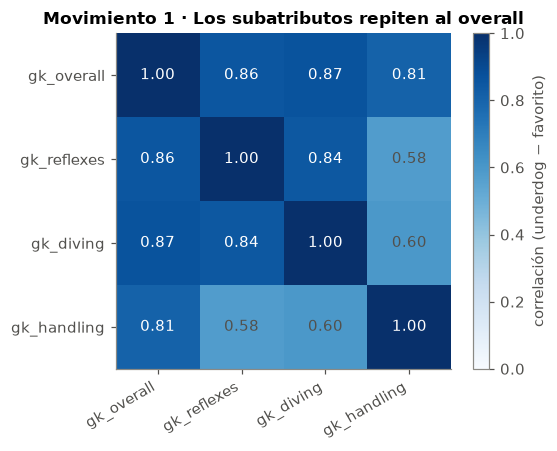

In [12]:
lineups = pd.read_parquet(INTERMEDIATE_DIR / "lineup_features.parquet").rename(columns={"match_api_id": "match_id"})
lineups = df[["match_id", "underdog_local"]].merge(lineups, on="match_id", validate="one_to_one")
GK = ["gk_overall", "gk_reflexes", "gk_diving", "gk_handling"]


def underdog_minus_favourite(frame, metric):
    home, away = frame[f"home_{metric}"], frame[f"away_{metric}"]
    return np.where(frame["underdog_local"] == 1, home - away, away - home)


for metric in GK[1:]:
    df[f"nofav_{metric}_gap"] = underdog_minus_favourite(lineups, metric)
gk_corr = df[[f"nofav_{m}_gap" for m in GK]].corr()
gk_corr.index = gk_corr.columns = GK

fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(gk_corr.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(4), GK, rotation=30, ha="right")
ax.set_yticks(range(4), GK)
ax.grid(False)
for i in range(4):
    for j in range(4):
        v = gk_corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.6 else INK)
fig.colorbar(im, ax=ax, fraction=0.046, label="correlación (underdog − favorito)")
ax.set_title("Movimiento 1 · Los subatributos repiten al overall")
plt.tight_layout()
plt.show()

In [13]:
h3 = compare(df, {
    "mercado + XI": (MARKET + ["nofav_xi_overall_mean_gap"],),
    "+ gk_overall": (MARKET + ["nofav_xi_overall_mean_gap", "nofav_gk_overall_gap"],),
    "+ reflejos, estirada, manejo": (MARKET + ["nofav_xi_overall_mean_gap", "nofav_gk_overall_gap", "nofav_gk_reflexes_gap", "nofav_gk_diving_gap", "nofav_gk_handling_gap"],),
})
h3

,log_loss_test,auc_test,parametros,Δ log_loss vs 1ra,Δ AUC vs 1ra,LR p vs fila anterior
mercado + XI,0.4895,0.6496,4.0,0.0000,0.0000,NaN
+ gk_overall,0.4897,0.6490,5.0,0.0002,-0.0006,0.0015
"+ reflejos, estirada, manejo",0.4898,0.6487,8.0,0.0003,-0.0009,0.2521


**4. Resultado.**
- Movimiento 1: como diferencia underdog − favorito, `gk_overall` correlaciona **0,86** con reflejos, **0,87** con estirada y
  **0,81** con manejo. Para el arquero, el overall ya es casi una combinación de esos tres.
- Movimiento 2: agregar los tres subatributos **empeora** la predicción fuera de muestra (log-loss +0,0001, AUC −0,0003) y
  la mejora dentro de muestra es la esperable por azar (**LR p = 0,25**, 3 grados de libertad).
- De paso, `gk_overall` solo mejora el ajuste dentro de muestra (p = 0,0015) pero tampoco mejora fuera de muestra.

**5. Zona:** 🔴 **refutada.**

**6. Decisión.** **SALEN** las 6 columnas `home_/away_gk_reflexes/diving/handling`. El arquero queda representado
por `nofav_gk_overall_gap` (zona amarilla por la evidencia mixta).

## H4 · Las columnas `home_*` / `away_*` son redundantes frente a los `nofav_*_gap`

| | |
|---|---|
| **1. Hipótesis** | Para responder "¿gana el underdog?" alcanza con la **diferencia** underdog − favorito de cada métrica. Los niveles de cada equipo (`home_*`, `away_*`) y las diferencias local − visitante (`*_gap`) no agregan información. |
| **2. Por qué podría ser cierta** | Las diferencias local − visitante son, por construcción, los `nofav_*_gap` con el signo invertido cuando el underdog es visitante. Los niveles sí podrían agregar algo ("dos equipos buenos" vs. "dos equipos malos"), y eso hay que medirlo. |
| **3. Movimientos** | (1) Gap local − visitante vs. gap underdog − favorito del XI: ¿es derivable exactamente? (2) Mercado + 16 gaps vs. mercado + 16 gaps + 16 niveles, fuera de muestra. |
| **Tipo** | Decide sobre **columnas**: 42 columnas `home_*/away_*` y 10 `*_gap` de la Entrega 1. |

máx |(gap local-visitante) - (±nofav gap)| = 0.0000


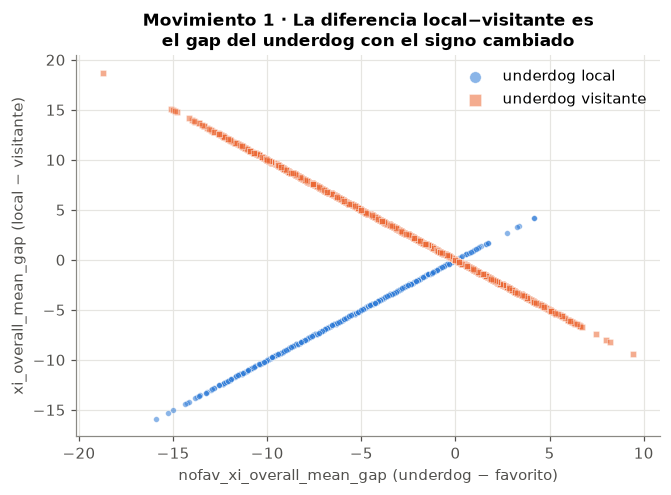

In [14]:
home_minus_away = lineups["home_xi_overall_mean"] - lineups["away_xi_overall_mean"]
max_diff = np.nanmax(np.abs(np.where(df["underdog_local"] == 1, df["nofav_xi_overall_mean_gap"], -df["nofav_xi_overall_mean_gap"]) - home_minus_away.round(4)))
print(f"máx |(gap local-visitante) - (±nofav gap)| = {max_diff:.4f}")

sample = df.assign(home_minus_away=home_minus_away.values).sample(4000, random_state=0)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
for flag, color, marker, label in ((1, BLUE, "o", "underdog local"), (0, ORANGE, "s", "underdog visitante")):
    part = sample[sample["underdog_local"] == flag]
    ax.scatter(part["nofav_xi_overall_mean_gap"], part["home_minus_away"], s=14, color=color, marker=marker, alpha=0.55,
               edgecolors="white", linewidths=0.4, label=label)
ax.set_xlabel("nofav_xi_overall_mean_gap (underdog − favorito)")
ax.set_ylabel("xi_overall_mean_gap (local − visitante)")
ax.set_title("Movimiento 1 · La diferencia local−visitante es\nel gap del underdog con el signo cambiado")
ax.legend(loc="upper right", markerscale=2)
plt.tight_layout()
plt.show()

In [15]:
GAPS = [c for c in catalog.FEATURE_COLUMNS if c.endswith("_gap")]
for metric in catalog.GAP_METRICS:
    df[f"nivel_underdog_{metric}"] = np.where(df["underdog_local"] == 1, lineups[f"home_{metric}"], lineups[f"away_{metric}"])
LEVELS = [f"nivel_underdog_{m}" for m in catalog.GAP_METRICS]
print(f"{len(GAPS)} gaps, {len(LEVELS)} niveles (con el gap, el nivel del underdog define también el del favorito)")
h4 = compare(df, {
    "mercado + 16 gaps": (MARKET + GAPS,),
    "+ 16 niveles": (MARKET + GAPS + LEVELS,),
})
h4

16 gaps, 16 niveles (con el gap, el nivel del underdog define también el del favorito)


,log_loss_test,auc_test,parametros,Δ log_loss vs 1ra,Δ AUC vs 1ra,LR p vs fila anterior
mercado + 16 gaps,0.4889,0.6513,19.0,0.0000,0.0000,NaN
+ 16 niveles,0.4895,0.6481,35.0,0.0006,-0.0031,0.422


**4. Resultado.**
- Movimiento 1: los puntos caen sobre dos rectas exactas (y = x si el underdog es local, y = −x si es visitante). La diferencia máxima
  es **0,0000**: las 10 columnas `*_gap` local − visitante son **exactamente derivables** de `nofav_*_gap` + `equipo_favorito`.
- Movimiento 2: sumar los niveles (16 columnas más) **empeora** la predicción fuera de muestra (log-loss +0,0006, AUC
  **0,651 → 0,648**) y la mejora dentro de muestra no supera al azar (**LR p = 0,42**, 16 grados de libertad).

**5. Zona:** 🟢 **confirmada.**

**6. Decisión.** **TRANSFORMAR**: las 32 columnas de nivel `home_*/away_*` de las 16 métricas se reemplazan por 16
`nofav_*_gap`, y las formaciones se orientan a `nofav_formacion` / `fav_formacion`. Las 10 `*_gap` local − visitante **SALEN**.
Ninguna métrica de la Entrega 1 se pierde: arquero, mejor jugador, top 3, peor, promedio, velocidad, definición, reacción,
marca, fuerza, líneas, edad, altura y formación siguen en Silver, orientados a la pregunta. Los niveles quedan en
`intermediate/lineup_features.parquet` para auditar.

---
# Parte 3 — Tabla de columnas candidatas

Todas las columnas consideradas: las 82 de la Entrega 1 más las nuevas. La tabla sale de `include/src/columns.py`, el mismo
catálogo que usa el pipeline para armar Silver y los quality checks. Así lo que dice la tabla es lo que hace el código.

In [16]:
candidates_table = catalog.catalog_frame().rename(columns={
    "name": "columna", "description": "qué mide", "zone": "zona", "decision": "decisión", "origin": "origen",
    "dtype": "tipo", "reason": "motivo", "location": "dónde queda", "available": "momento",
})
candidates_table["¿existiría al predecir?"] = np.where(candidates_table["momento"] == catalog.PRE, "SÍ", "NO")
view = candidates_table[["columna", "qué mide", "origen", "tipo", "zona", "decisión", "¿existiría al predecir?", "dónde queda", "motivo"]]
print(view["decisión"].value_counts().to_dict())
with pd.option_context("display.max_rows", 200, "display.max_colwidth", 90):
    display(view)

{'TRANSFORMAR': 36, 'ENTRA': 21, 'SALE': 19, 'SOLO AUDITORÍA': 12, 'AUXILIAR': 6, 'IDENTIFICADOR': 2, 'TARGET': 1}


,columna,qué mide,origen,tipo,zona,decisión,¿existiría al predecir?,dónde queda,motivo
0,match_id,Identificador del partido (clave primaria: una fila = un partido).,fuente,entero,—,IDENTIFICADOR,SÍ,silver,"Clave, no feature: su valor no dice nada del partido."
1,fecha,Fecha del partido.,fuente,fecha,—,AUXILIAR,SÍ,silver,Se conserva para separar train/test en el tiempo; no es feature.
2,temporada,Temporada (ej. 2012/2013).,fuente,texto,—,AUXILIAR,SÍ,silver,Se conserva para cortes temporales; como feature solo identificaría la época.
3,jornada,Número de fecha dentro de la temporada.,fuente,entero,amarillo,ENTRA,SÍ,silver,"Pre-partido y barata, pero sin señal marginal en el EDA (tasa real - probabilidad impl..."
4,liga,Liga del partido.,fuente,categórica,amarillo,ENTRA,SÍ,silver,"Pre-partido. Señal débil (test de razón de verosimilitud p = 0,06; tasa real - probabi..."
5,odds_source,"Casa de apuestas de la que salen las cuotas de la fila (PS = Pinnacle, B365 = Bet365, ...",calculada,texto,—,AUXILIAR,SÍ,silver,"Trazabilidad. No es feature: está confundida con la época (B365 hasta 2011/12, PS desd..."
6,prob_home,Probabilidad implícita normalizada de victoria local.,calculada,decimal,—,AUXILIAR,SÍ,silver,Define al favorito y valida prob_home + prob_draw + prob_away = 1. Como feature es red...
7,prob_draw,Probabilidad implícita normalizada de empate.,calculada,decimal,verde,ENTRA,SÍ,silver,Precio de mercado anterior al partido. Un empate también es 'no gana el underdog'.
8,prob_away,Probabilidad implícita normalizada de victoria visitante.,calculada,decimal,—,AUXILIAR,SÍ,silver,Idem prob_home.
9,equipo_favorito,Qué equipo es el favorito: 'local' o 'visitante'.,calculada,categórica,verde,ENTRA,SÍ,silver,"Ubica la localía del underdog: el underdog local gana 0,6 pp más de lo que dice el mer..."


**Decisión.** Entran al modelo las columnas `ENTRA` y `TRANSFORMAR` que están en Silver (23 features). `AUXILIAR` e
`IDENTIFICADOR` quedan en Silver para cortar, trazar y validar, pero **no** son features. `SOLO AUDITORÍA` vive en
`include/data/audit/` y se une por `match_id` solo para leer resultados. Todo lo que es post-partido está ahí, no en Silver.

---
# Parte 4 — Control final de data leakage

In [17]:
leakage = catalog.leakage_audit_frame(list(silver.columns))
X, y = catalog.split_features_target(silver)
aucs = pd.Series({c: single_feature_auc(X[c], y) for c in X.columns if pd.api.types.is_numeric_dtype(X[c])}).sort_values(ascending=False)

assert not leakage["leakage"].any(), "hay columnas con fuga en Silver"
assert TARGET_COLUMN not in X.columns and not set(X.columns) & set(catalog.LEAKAGE_COLUMNS)
assert all(spec[c].available == catalog.PRE for c in X.columns)
print(f"X: {X.shape[1]} features, todas pre-partido | y = {TARGET_COLUMN} ({y.mean():.2%} positivos)")
print(f"Columnas con fuga en Silver: {int(leakage['leakage'].sum())} | columnas post-partido conocidas: {catalog.LEAKAGE_COLUMNS}")
print(f"Mejor AUC de una sola feature: {aucs.index[0]} = {aucs.iloc[0]:.3f} (una columna con el resultado adentro daría ~1)")
print("Quality checks del pipeline:", "todos OK" if run_quality_checks(silver)["passed"] else "FALLAN")
leakage

X: 23 features, todas pre-partido | y = gano_no_favorito (20.35% positivos)
Columnas con fuga en Silver: 0 | columnas post-partido conocidas: ['away_team_goal', 'card', 'corner', 'cross', 'foulcommit', 'goal', 'goles_local', 'goles_visitante', 'home_team_goal', 'possession', 'resultado_ft', 'resultado_no_favorito', 'shotoff', 'shoton']
Mejor AUC de una sola feature: prob_no_favorito = 0.638 (una columna con el resultado adentro daría ~1)
Quality checks del pipeline: todos OK


,columna,origen,momento_disponible,feature,target,leakage,decision
0,match_id,fuente,pre-partido,False,False,False,IDENTIFICADOR
1,fecha,fuente,pre-partido,False,False,False,AUXILIAR
2,temporada,fuente,pre-partido,False,False,False,AUXILIAR
3,jornada,fuente,pre-partido,True,False,False,ENTRA
4,liga,fuente,pre-partido,True,False,False,ENTRA
5,odds_source,calculada,pre-partido,False,False,False,AUXILIAR
6,prob_home,calculada,pre-partido,False,False,False,AUXILIAR
7,prob_draw,calculada,pre-partido,True,False,False,ENTRA
8,prob_away,calculada,pre-partido,False,False,False,AUXILIAR
9,equipo_favorito,calculada,pre-partido,True,False,False,ENTRA


**Resultado.** Ninguna de las 31 columnas de Silver es post-partido. X tiene 23 features y todas existen antes del pitazo.
La mejor feature sola (`prob_no_favorito`) tiene un AUC de 0,64: es información de mercado, no del resultado. Goles, resultado final y
resultado del underdog están solo en `audit/`. El target es exactamente "ganó el underdog" según esos goles
(lo verifica `tests/test_silver_dataset.py`).

---
# Conclusiones y decisiones para el modelado

| Tema | Decisión | Evidencia |
|---|---|---|
| Filas | 17.959 partidos; umbral de underdog **0,05** (se filtra) | H1: sobre ese umbral el underdog no depende de la casa (0% de discrepancias Pinnacle/Bet365) |
| Target | 20,35% positivo; sin nulos; no se rebalancea | Perfil; métricas AUC/log-loss |
| Base del modelo | Mercado: `prob_no_favorito`, `prob_draw`, `equipo_favorito` | AUC 0,647 fuera de muestra |
| Jugadores | Diferencias `nofav_*_gap` (16) + formaciones orientadas | H4: los niveles no suman (p = 0,42) |
| Arquero | Solo `gk_overall` | H3: subatributos refutados (p = 0,25) |
| Expectativa | Mejora chica sobre el mercado | H2 inconclusa: +0,003 de AUC |
| Leakage | Goles y resultados fuera de Silver | Parte 4 + hard checks del DAG |